# BhuvanFitter — gene-expression distribution fitting

Per-gene tools, imported from `bhuvanfitter.py` (the single source of truth).
`BhuvanFitter` supports two fit models via the same `fit()` / `hist()` interface:

- **`fit("fourparam")`** — fits a 4-parameter Gaussian to the 40-bin histogram by
  ordinary least squares and returns
  `gene, y0, A, x0, w, sumsquarevalue, ti_fourparam_sigma_dist, truncationindex,
  min, max, right, maxheight, rightheight, n_obs, fit_success`. The
  truncation-index metrics use `x_max` (default = observed max):
  **`ti_fourparam_sigma_dist`** = `(x_max − x0) / (w/√2)` and **`truncationindex`**
  = `rightheight / maxheight`, with the fitted curve's interval-minimum subtracted
  from both, so it is **bounded to [0, 1]** (NaN only for a flat fitted curve).
- **`fit("kde")`** — runs a bin-independent Gaussian KDE and detects its modes
  (reusing `gene_peaks`), returning `gene, n_peaks, peaks, bw_method, n_obs,
  fit_success`, where `peaks` is `{value: {"height", "prominence"}}`.

`hist(lines=["fourparam", "kde"])` overlays either/both fitted curves on the
histogram (the KDE scaled to bin counts, with markers at detected peaks), but
only after the corresponding `fit` has been run.

## 1. Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The fitting library is the single source of truth (bhuvanfitter.py) — the
# model, the BhuvanFitter class, and gene_peaks all live there.
from bhuvanfitter import BhuvanFitter, gene_peaks

## 2. The 4-Parameter Gaussian Model

$$y = y_0 + A \cdot \exp\!\left(-\left(\frac{x - x_0}{w}\right)^2\right)$$

| Parameter | Meaning |
|---|---|
| `y0` | Baseline offset |
| `A`  | Amplitude (peak height above baseline) |
| `x0` | Centre of the peak |
| `w`  | Width parameter (`w = σ√2`) |

Lives in `bhuvanfitter.py` as the module-level `_fourparam_gaussian` (module
level because `scipy.optimize.curve_fit` needs a plain picklable callable). It is
imported above with `BhuvanFitter` — do **not** redefine it here, or the inline
copy will shadow the import and break (it would need its own `curve_fit` import).

## 3. The `BhuvanFitter` Class

The main interface, imported from `bhuvanfitter.py` (cell 1). It cleans the data,
caches a 40-bin histogram, and dispatches fits through `fit(model)`:

- `fit("fourparam")` — 4-parameter Gaussian by ordinary least squares + the
  truncation-index metrics.
- `fit("kde")` — Gaussian KDE mode detection (reuses `gene_peaks`).

`hist(lines=[...])` overlays any fits that have been run. All analysis logic lives
in the module so the notebook, `generate_fourparam_stats.py`, and
`generate_peaks.py` share one implementation — keep it imported, not redefined.

## 4. Example

A quick synthetic check: fit a Gaussian sample and overlay the fitted curve.

In [ ]:
fourparam_df = pd.read_csv("cerebellumlog2_fourparam_table_excluded_at_or_below_-1.csv")
master = pd.read_csv('cerebellumlog2.csv').drop(columns=['Description']).set_index('Name')
master = master.T

# Minimum post-exclusion samples for a gene's fit to be trusted. The generator's
# MIN_OBS=10 is too low for a 4-param fit to a 40-bin histogram (SD error ~24% at n=10);
# 30 gives ~13% SD error. Filtering here is identical to regenerating the table with this
# floor, since a gene's fit doesn't depend on MIN_OBS once n_obs clears it.
MIN_OBS = 30


def select(param):
    """Filtered column for plotting: fit_success genes with 0 < truncationindex < 1
    and n_obs >= MIN_OBS, NaNs dropped. This is the single place to change the shared filter."""
    mask = (fourparam_df['fit_success'] == True) & (fourparam_df['truncationindex'] > 0) & (fourparam_df['truncationindex'] < 1) & (fourparam_df['n_obs'] >= MIN_OBS)
    return fourparam_df.loc[mask, param].dropna()


def plot_param_hist(param, *, color='skyblue', bins=40, log=False):
    """Log-y histogram of `param` over the genes returned by select(). Returns the
    plotted data so callers can print counts / stats."""
    data = select(param)

    # Filtering funnel — mirrors select(), one print per stage.
    after_success = fourparam_df[fourparam_df['fit_success'] == True]
    after_nan = after_success[after_success[param].notna()]
    after_trunc_lower = after_nan[after_nan['truncationindex'] > 0]
    after_trunc_upper = after_trunc_lower[after_trunc_lower['truncationindex'] < 1]
    after_nobs = after_trunc_upper[after_trunc_upper['n_obs'] >= MIN_OBS]
    print(f"Total genes in master:            {master.shape[1]}")
    print(f"Total genes in fourparam_df:      {len(fourparam_df)}")
    print(f"After fit_success == True:        {len(after_success)}")
    print(f"After dropping NaN {param}: {len(after_nan)}")
    print(f"After truncationindex > 0:        {len(after_trunc_lower)}")
    print(f"After truncationindex < 1:        {len(after_trunc_upper)}")
    print(f"After n_obs >= {MIN_OBS}:              {len(after_nobs)}")

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, color=color, edgecolor='black')
    plt.title(f'Histogram of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency (Log Scale)' if log else 'Frequency')
    if log:
        plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return data


def plot_gene_stat_hist(stat='mean', source='table', *, color=None, bins=40):
    """One-line histogram, over the filtered genes (select()), of a per-gene expression
    summary. Returns the plotted Series.
      stat   : 'mean' or 'std'
      source : 'full'  -> computed from `master` over ALL samples (incl. the -1 floor)
               'table' -> the post-exclusion fourparam_df[stat] column (only > -1 samples)
    Pair mean/std calls with the same `source` if you feed them to the scatter."""
    if source == 'full':
        values = getattr(master[select('gene')], stat)(axis=0).dropna()
    elif source == 'table':
        values = select(stat)
    else:
        raise ValueError("source must be 'full' or 'table'")
    color = color or ('mediumseagreen' if stat == 'mean' else 'cornflowerblue')
    label = {'mean': 'average', 'std': 'standard deviation'}[stat]
    print(f"Number of filtered genes: {len(values)}")

    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins, color=color, edgecolor='black')
    plt.title(f'Per-gene {label} expression ({source} samples, filtered genes)')
    plt.xlabel('Average expression' if stat == 'mean' else 'Standard deviation')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return values

Total genes in master:            74628
Total genes in fourparam_df:      74628
After fit_success == True:        48888
After dropping NaN sumsquarevalue: 48888
After truncationindex > 0:        13922
After truncationindex < 1:        13917
After n_obs >= 30:              13644


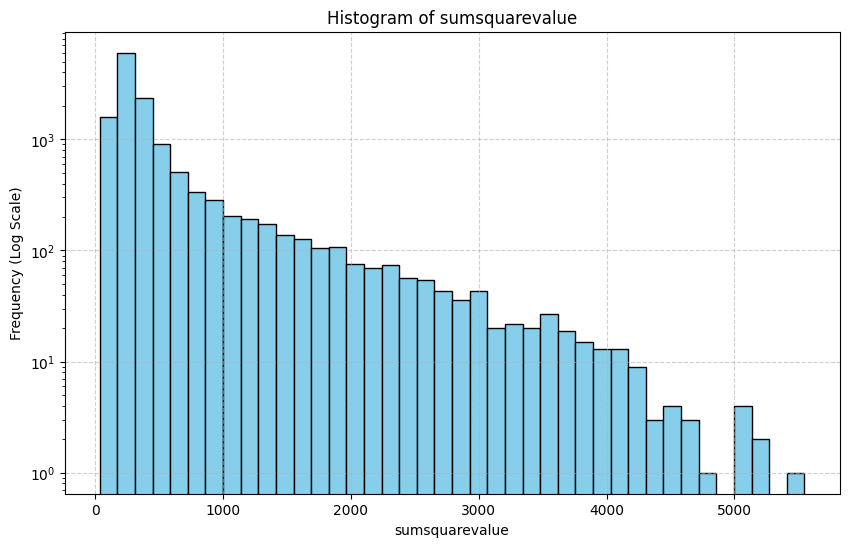

9        116.747311
12       296.338711
14       359.849958
19       356.541556
22       434.451898
            ...    
74335    268.972816
74340    251.055878
74341    221.432318
74343    502.106863
74624    428.121523
Name: sumsquarevalue, Length: 13644, dtype: float64

In [11]:
plot_param_hist('sumsquarevalue', log = True)

Total genes in master:            74628
Total genes in fourparam_df:      74628
After fit_success == True:        48888
After dropping NaN truncationindex: 48250
After truncationindex > 0:        13922
After truncationindex < 1:        13917
After n_obs >= 30:              13644


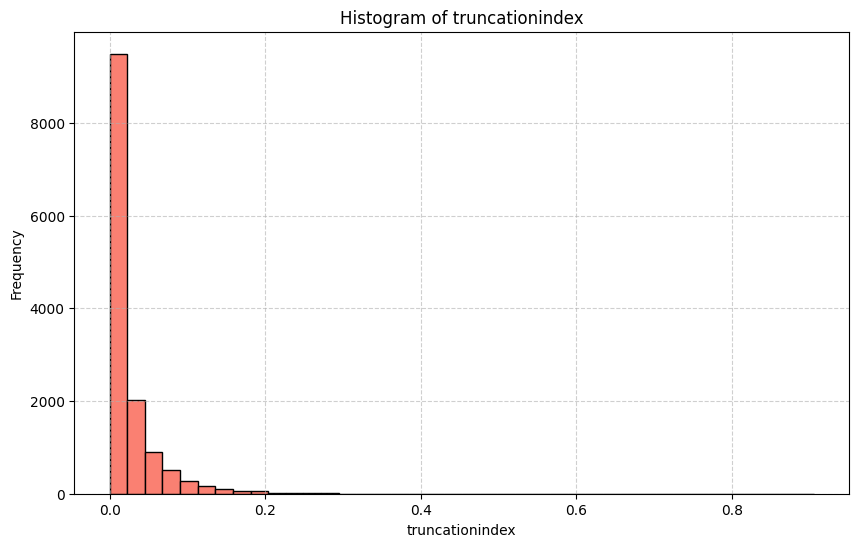

In [ ]:
# Distribution of truncationindex across genes that fit successfully.
# truncationindex = rightheight / maxheight, with the fitted curve's interval-minimum
# baseline subtracted from both, so it is bounded to [0, 1] (0 = ceiling at the curve
# minimum, 1 = ceiling at the peak). NaN only for a flat fitted curve.
ti = plot_param_hist('truncationindex', color='salmon', log = False)

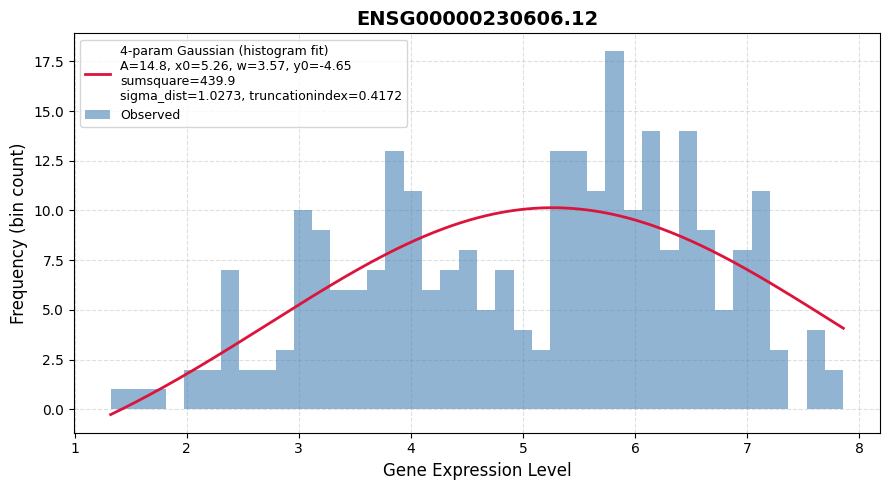

<Axes: title={'center': 'ENSG00000230606.12'}, xlabel='Gene Expression Level', ylabel='Frequency (bin count)'>

In [13]:
fitter = BhuvanFitter(master['ENSG00000230606.12'], "ENSG00000230606.12")
fitter.fit("fourparam")     # runs the 4-param Gaussian
# fitter.fit("kde")           # runs the KDE fit
fitter.hist(lines=["fourparam"])   # overlay both

Number of filtered genes: 13644


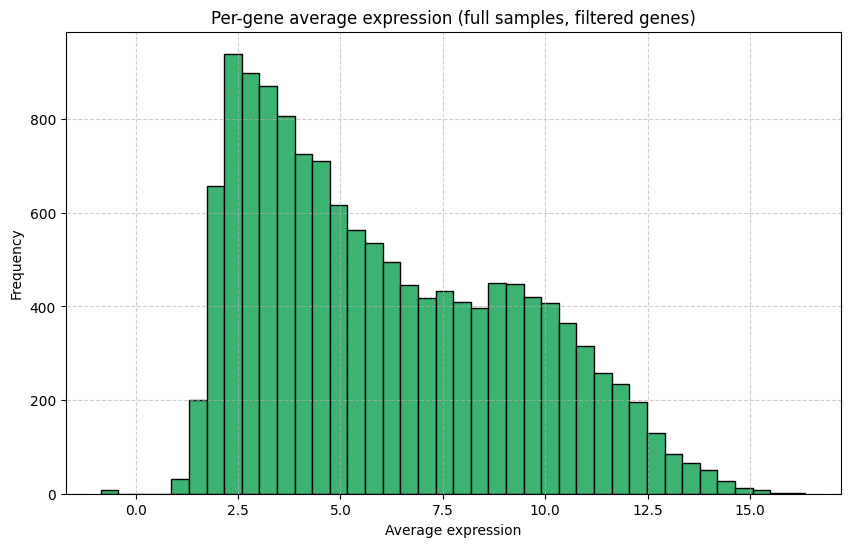

In [14]:
# Per-gene average expression over the filtered genes (source='full' = all 266 samples
# incl. the -1 floor; use source='table' for the post-exclusion fourparam_df['mean']).
strain_avgs = plot_gene_stat_hist('mean')

Number of filtered genes: 13644


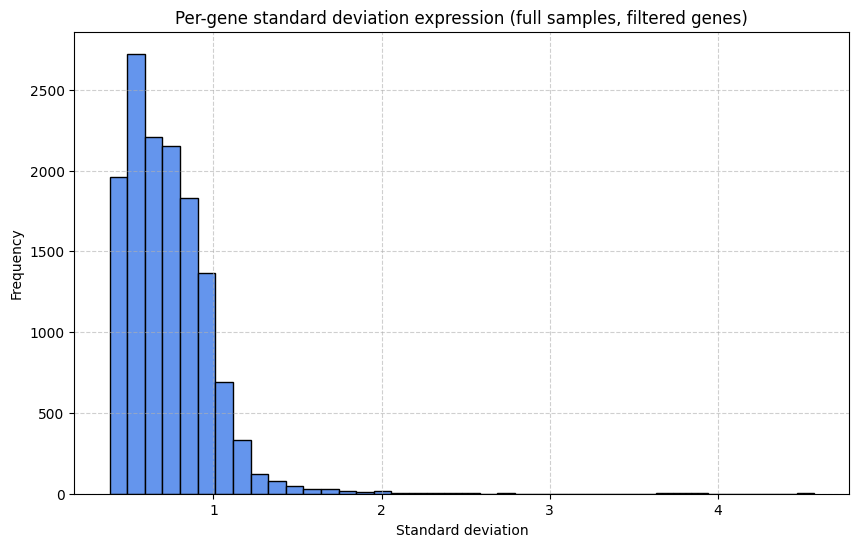

In [15]:
# Per-gene expression standard deviation over the same filtered genes. Keep the same
# `source` as the mean call above so the two align for the scatter below.
strain_sds = plot_gene_stat_hist('std')

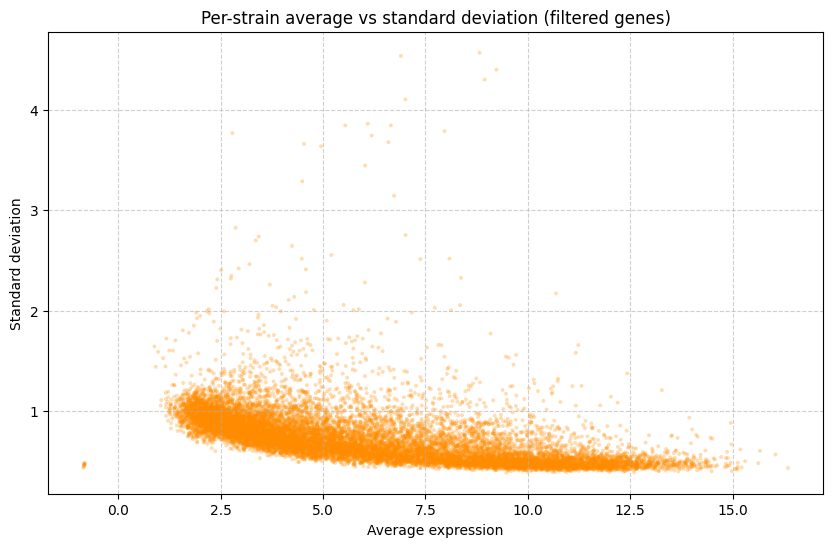

In [16]:
# Mean vs SD per filtered gene/strain column. strain_avgs and strain_sds are both
# indexed by gene from filtered_master, so they align by index for the scatter.
plt.figure(figsize=(10, 6))
plt.scatter(strain_avgs, strain_sds, s=8, alpha=0.3, color='darkorange', edgecolors='none')
plt.title('Per-strain average vs standard deviation (filtered genes)')
plt.xlabel('Average expression')
plt.ylabel('Standard deviation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. pTriplo vs. the fourparam features

pTriplo (Collins 2022 triplosensitivity score, `dosage_sensitivity_collins2022.tsv.gz`,
"high" cutoff ≥ 0.94) and the truncation index are **both continuous classifier scores**
for triplosensitivity — neither is ground truth. This section is the descriptive
"agreement" view: the correlation of pTriplo with **every numeric fourparam feature**
over the cerebellum genes.

The fourparam table is keyed by Ensembl IDs and pTriplo by gene symbols; the GTEx source
`cerebellumlog2.csv` carries both (`Name` = ENSG, `Description` = symbol), so the join needs
no external lookup (~15.5k genes after the `fit_success` filter).

In [ ]:
# Correlation of pTriplo with every numeric fourparam feature (cerebellum genes).
from scipy.stats import spearmanr, pearsonr

# ENSG (version-stripped) -> gene symbol, straight from the GTEx source's two id columns.
_idmap = pd.read_csv("cerebellumlog2.csv", usecols=["Name", "Description"])
_sym = dict(zip(_idmap["Name"].str.split(".").str[0], _idmap["Description"]))

# pTriplo, keyed by symbol (strip the leading '#' off the header line).
ptriplo = pd.read_csv("dosage_sensitivity_collins2022.tsv.gz", sep="\t")
ptriplo.columns = [c.lstrip("#") for c in ptriplo.columns]

# Attach symbols to the successfully-fit genes and inner-join pTriplo.
ce = fourparam_df[fourparam_df["fit_success"] == True].copy()
ce["symbol"] = ce["gene"].str.split(".").str[0].map(_sym)
merged = ce.merge(ptriplo[["gene", "pTriplo"]], left_on="symbol", right_on="gene",
                  how="inner", suffixes=("", "_pt"))
print(f"Genes merged (fit_success & in pTriplo): {len(merged)}")

features = ["y0", "A", "x0", "w", "sumsquarevalue", "ti_fourparam_sigma_dist",
            "truncationindex", "min", "max", "mean", "std", "right",
            "maxheight", "rightheight", "n_obs"]

rows = []
for f in features:
    sub = merged[[f, "pTriplo"]].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(sub)
    rho = spearmanr(sub[f], sub["pTriplo"]).correlation if n >= 3 else np.nan
    pr = pearsonr(sub[f], sub["pTriplo"])[0] if n >= 3 else np.nan
    rows.append({"feature": f, "spearman_rho": rho, "pearson_r": pr, "n": n})

ptriplo_corr = (pd.DataFrame(rows)
                .assign(abs_rho=lambda d: d["spearman_rho"].abs())
                .sort_values("abs_rho", ascending=False)
                .drop(columns="abs_rho")
                .reset_index(drop=True))
ptriplo_corr

In [ ]:
# Scatter of pTriplo vs. one feature. Default is truncationindex (the headline classifier);
# set `feat` to any row of ptriplo_corr to inspect another.
feat = "truncationindex"
sub = merged[[feat, "pTriplo"]].replace([np.inf, -np.inf], np.nan).dropna()
rho = spearmanr(sub[feat], sub["pTriplo"]).correlation

plt.figure(figsize=(8, 6))
plt.scatter(sub[feat], sub["pTriplo"], s=6, alpha=0.25, color='teal', edgecolors='none')
plt.axhline(0.94, color='red', ls='--', lw=1, label='pTriplo = 0.94 (high triplo)')
plt.title(f'pTriplo vs {feat}   (n={len(sub)}, Spearman ρ={rho:.3f})')
plt.xlabel(feat)
plt.ylabel('pTriplo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()